In [2]:

import numpy as np
from past.types import basestring

from Data.Dataset.Dataset import Dataset

dataset = Dataset('test_1010.txt')
data = np.array(dataset.op_data)
data.shape

(10, 10, 2)

In [17]:
from GAS.Population import JSSP, print_console
from GAS.Individual import Individual
from Config.Run_Config import Run_Config
import random
import copy
config = Run_Config(dataset.n_job, dataset.n_machine, dataset.n_op,population_size=100, generations=400, 
                             print_console=False, save_log=False, save_machinelog=False, 
                             show_gantt=False, save_gantt=False, show_gui=False,
                             trace_object='Process4', title='Gantt Chart for JSSP',
                             tabu_search_iterations=10, hill_climbing_iterations=30, simulated_annealing_iterations=50,two_iterations=1000)
    
config.target_makespan = 1
jssp = JSSP(dataset, print_console=False)
makespan_list ={'A':[], 'B':[], 'C':[]}
rubi_score_list = {'A':[], 'B':[], 'C':[]}

for i in range(100):    
    seq=jssp.get_seq()
    random.shuffle(seq)
    individual = Individual(config, seq=seq, op_data=dataset.op_data)
    makespan_list['A'].append(individual.makespan)
    rubi_score_list['A'].append(individual.mio_score)
for i in range(100):    
    seq=jssp.get_seq()
    temp = copy.deepcopy(seq[i:])
    random.shuffle(temp)
    partial_seq = seq[:i]+temp
    individual = Individual(config, seq=partial_seq, op_data=dataset.op_data)
    makespan_list['B'].append(individual.makespan)
    rubi_score_list['B'].append(individual.mio_score)
for i in range(100):    
    seq=jssp.get_seq()
    individual = Individual(config, seq=seq, op_data=dataset.op_data)
    makespan_list['C'].append(individual.makespan)
    rubi_score_list['C'].append(individual.mio_score)

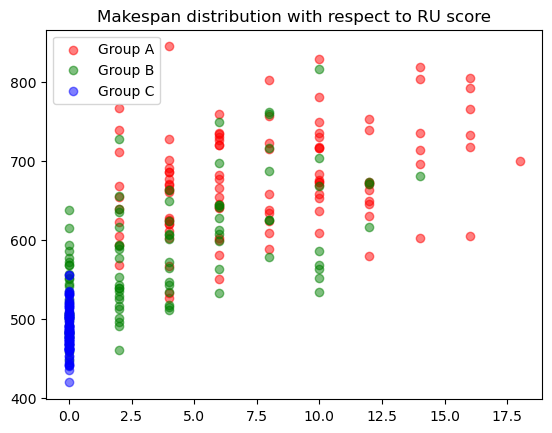

In [19]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(rubi_score_list['A'], makespan_list['A'],label='Group A', color='red',alpha=0.5)
plt.scatter(rubi_score_list['B'], makespan_list['B'],label='Group B', color='green',alpha=0.5)
plt.scatter(rubi_score_list['C'], makespan_list['C'],label='Group C', color='blue',alpha=0.5)
plt.legend()
plt.title("Makespan distribution with respect to RU score")
plt.show()
